In [1]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as md
from MDAnalysis.analysis.leaflet import LeafletFinder
import matplotlib.pyplot as plt

In [2]:
u1 = md.Universe("POPC/6N3C+POPC.gro","POPC/6N3C+POPC.xtc")
u2 = md.Universe("POPS/6N3C+POPS.gro","POPS/6N3C+POPS.xtc")
u3 = md.Universe("POPC+CHOL/6N3C+POPC+CHOL.gro","POPC+CHOL/6N3C+POPC+CHOL.xtc")
u4 = md.Universe("POPS+CHOL/6N3C+POPS+CHOL.gro","POPS+CHOL/6N3C+POPS+CHOL.xtc")

In [32]:
plt.rc("axes",linewidth=3)
plt.rc("legend",fontsize=18,frameon=False)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 22
plt.rcParams['font.family'] = "serif"
tdir = 'in'
major = 10.0
minor = 6.0
plt.rcParams['xtick.direction'] = tdir
plt.rcParams['ytick.direction'] = tdir
plt.rcParams['xtick.major.size'] = major
plt.rcParams['xtick.minor.size'] = minor
plt.rcParams['ytick.major.size'] = major

In [12]:
protein = u1.select_atoms('protein')
lipids = u1.select_atoms('resname POPC')
bilayer_normal = np.array([0, 0, 1])
residue_depths = []
for residue in protein.residues:
    residue_atoms = residue.atoms
    residue_center = residue_atoms.center_of_mass()
    depth = np.dot(residue_center - lipids.center_of_mass(), bilayer_normal)
    residue_depths.append(depth)
    
with open('residue_depths_popc.dat', 'w') as f:
    for residue, depth in zip(protein.residues, residue_depths):
        f.write('{} {} {}\n'.format(residue.resid,residue.resname, depth))

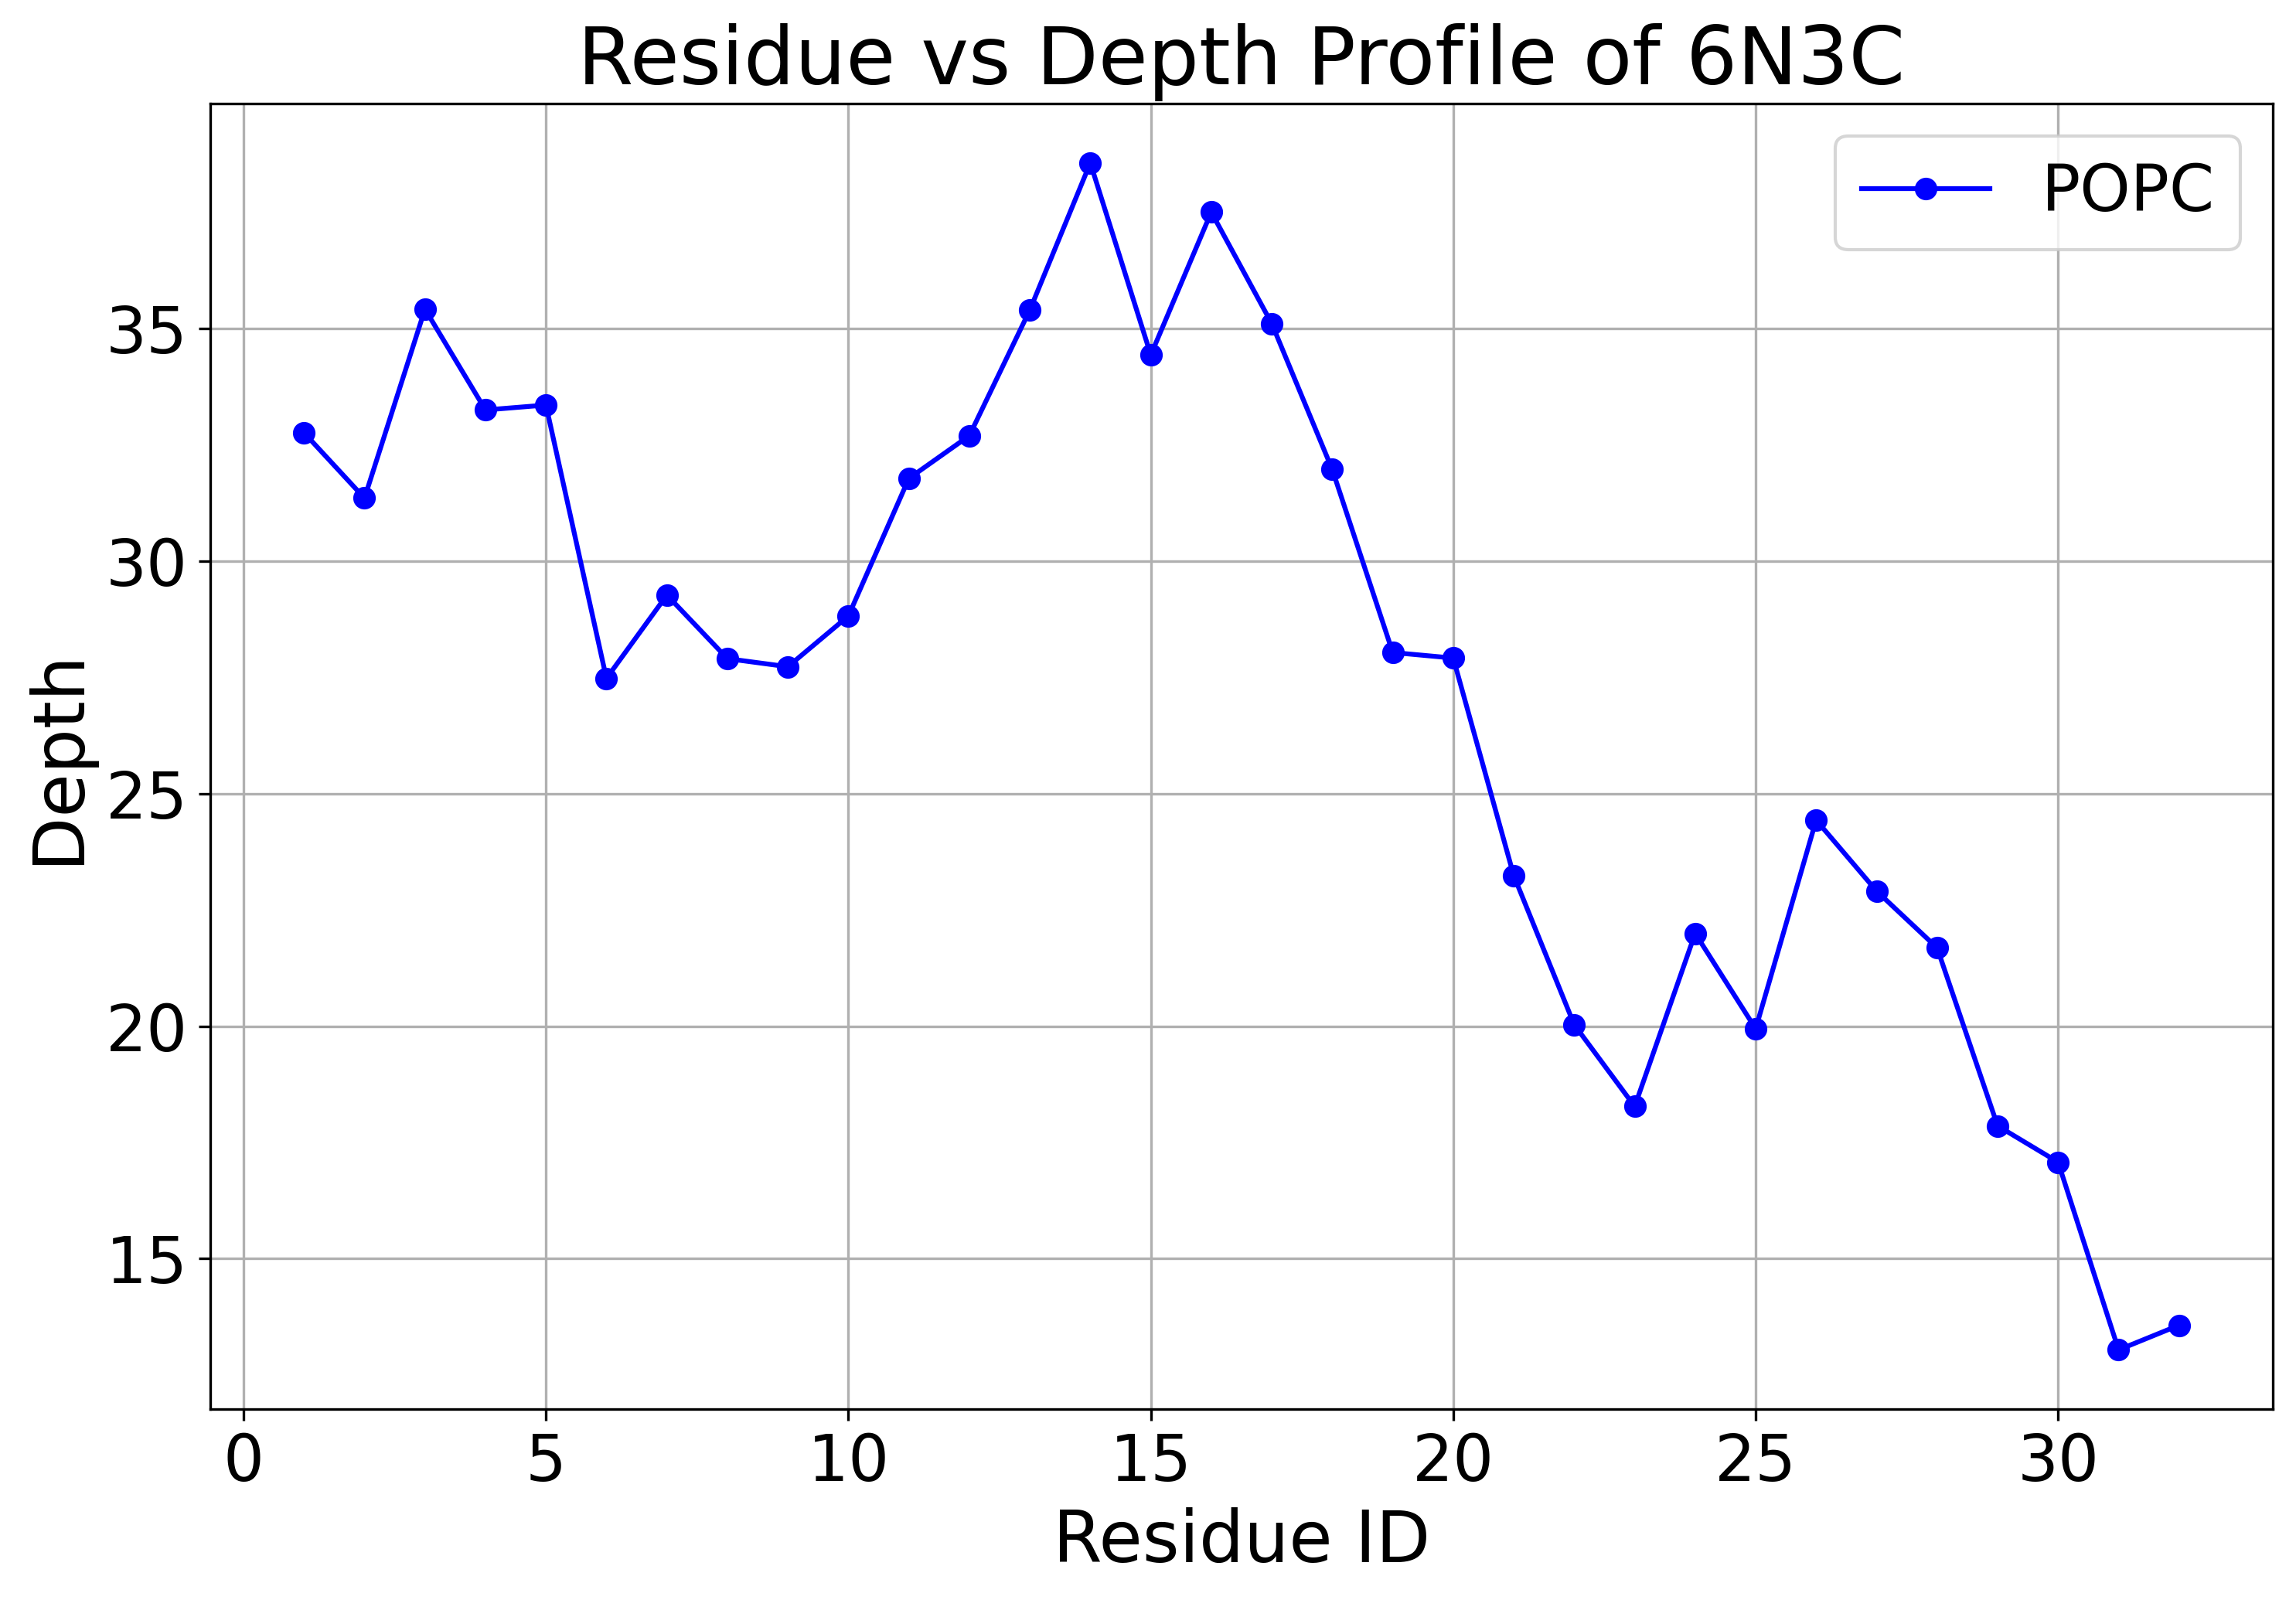

In [17]:
residues = []
depths = []

with open('residue_depths_popc.dat', 'r') as f:
    for line in f:
        fields = line.split()
        residue_id = int(fields[0])
        depth = float(fields[2])
        residues.append(residue_id)
        depths.append(depth)

adjusted_residues = [resid for resid in residues]

plt.figure(figsize=(10,7),dpi=300)
plt.plot(adjusted_residues, depths, marker='o', linestyle='-', color='b',label="POPC")
plt.xlabel('Residue ID',fontsize=22)
plt.ylabel('Depth',fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Residue vs Depth Profile of 6N3C',fontsize=25)
plt.legend(loc="upper right",fontsize=20)
plt.grid()
plt.tight_layout()
#plt.savefig("2N3X+POPC_depth_profile.png",dpi=300)
plt.show()

In [15]:
def calculate_residue_depth(u, lipid_selection, output_file):
    protein = u.select_atoms('protein')
    lipids = u.select_atoms(lipid_selection)
    bilayer_normal = np.array([0, 0, 1])
    residue_depths = {}
    
    for residue in protein.residues:
        residue_atoms = residue.atoms.select_atoms("name CA")
        residue_center = residue_atoms.positions
        depth = np.dot(residue_center - lipids.center_of_mass(), bilayer_normal)
        residue_depths[residue.resid] = depth[0] /10
    
    with open(output_file, 'w') as f:
        for resid, depth in residue_depths.items():
            f.write('{} {}\n'.format(resid, depth))
    
    return residue_depths

In [21]:
import matplotlib.pyplot as plt

def plot_residue_depth(residue_depths_list, titles, output_file, colors, labels=None):
    plt.figure(dpi=500)
    plt.rc("axes",linewidth=3)
    plt.rc("legend",fontsize=15,frameon=False)
    for i in range(len(residue_depths_list)):
        residues = list(residue_depths_list[i].keys())
        depths = list(residue_depths_list[i].values())
        
        plt.plot(residues, depths, marker='o', linestyle='-', color=colors[i], label=labels[i] if labels else None)
    plt.xlabel('Residue', fontsize=22)
    plt.ylabel('Depth(nm)', fontsize=22)
    plt.tick_params(axis = "both",which = "major",labelsize=18)

    
    if titles:
        plt.title(titles, fontsize=22)
    
    if labels:
        plt.legend(loc="best")
    
    plt.grid()
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=500)
    
    plt.show()

In [22]:
POPC = calculate_residue_depth(u1,"resname POPC","residue_depth_popc.dat")
POPS = calculate_residue_depth(u2,"resname POPS","residue_depth_pops.dat")
POPC_CHOL = calculate_residue_depth(u3,"resname POPC","residue_depth_popc_chol.dat")
POPS_CHOL = calculate_residue_depth(u4,"resname POPS","residue_depth_pops_chol.dat")

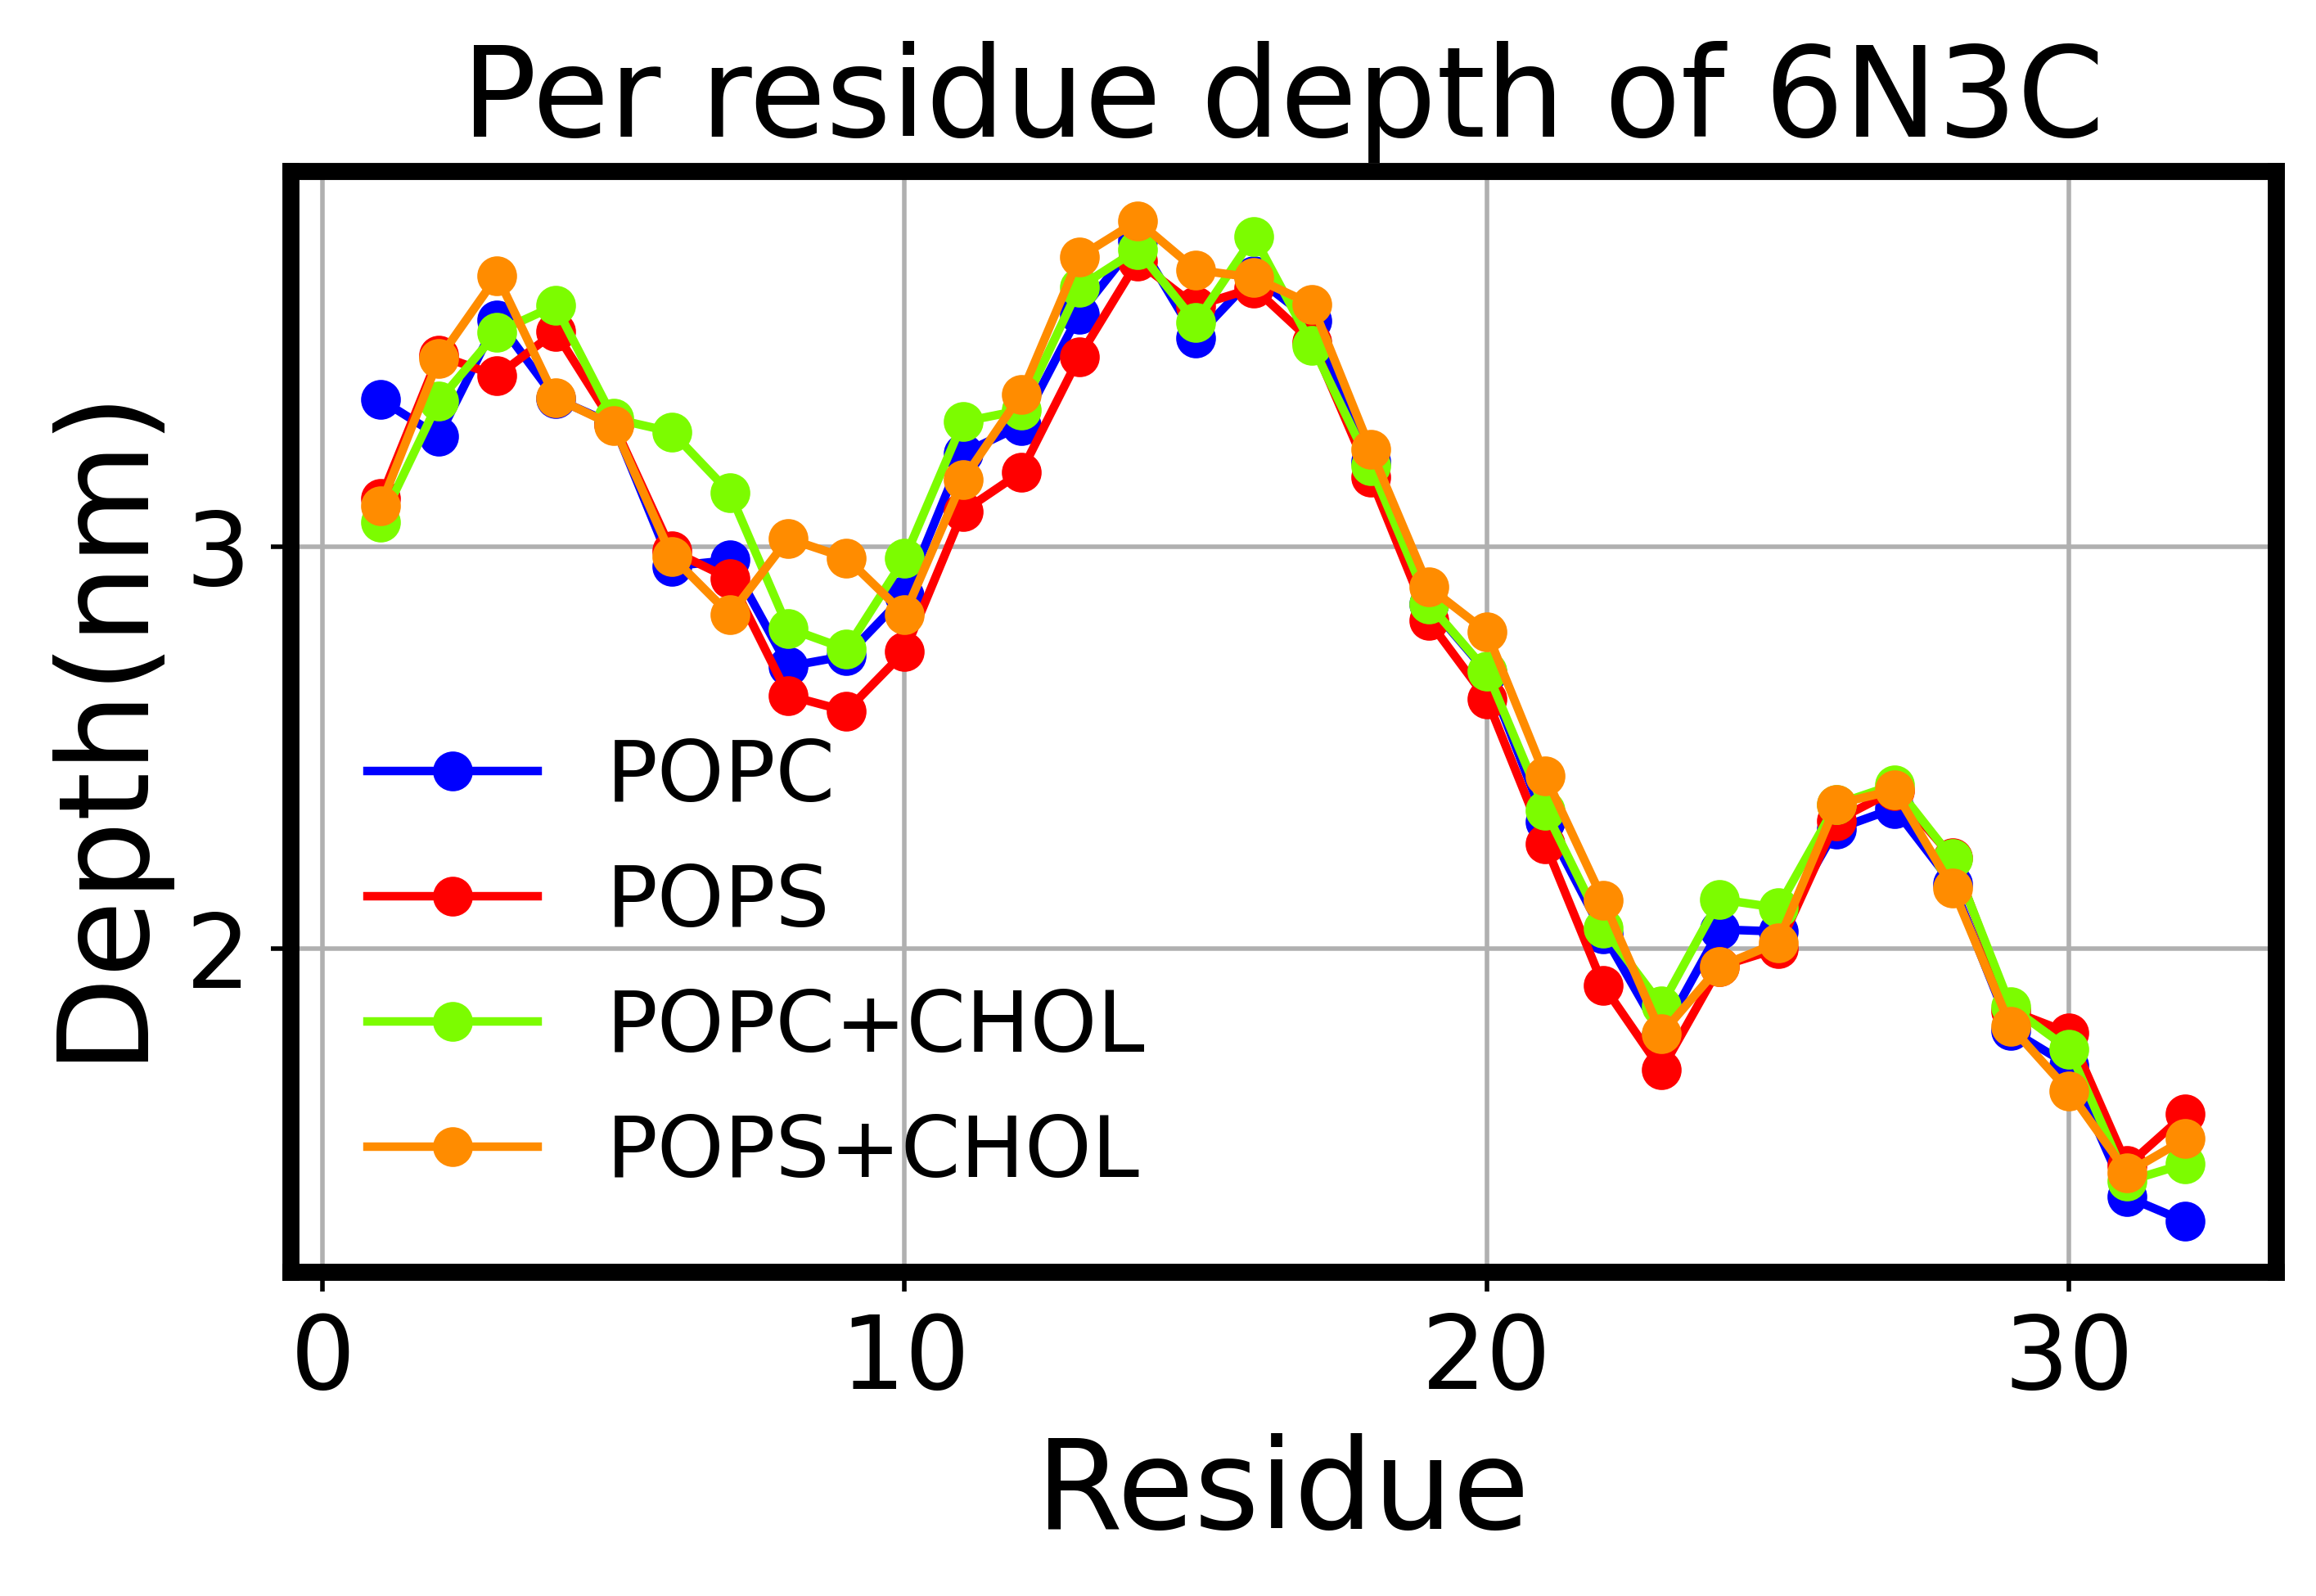

In [23]:
plot_residue_depth([POPC,POPS,POPC_CHOL,POPS_CHOL],"Per residue depth of 6N3C","Per_residue_depth_6N3C.png",
                   ["blue","red","lawngreen","darkorange"],labels=["POPC","POPS","POPC+CHOL","POPS+CHOL"])